In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader, ConcatDataset, random_split
import torchvision.transforms as transforms
import torchvision.models as models
from torch import optim
import json
import torch.optim.lr_scheduler as lr_scheduler
import os

from tqdm import tqdm
from utils import util_functions, metric_functions, custom_dataset

In [2]:
train_labels_path = os.path.join('dataset', 'train.csv')
test_labels_path = os.path.join('dataset', 'test.csv')

train_images_dir = os.path.join('dataset', 'train')
test_images_dir = os.path.join('dataset', 'test')

train_labels_df = pd.read_csv(train_labels_path)
test_labels_df = pd.read_csv(test_labels_path)

In [3]:
train_transformer = transforms.Compose([transforms.Resize((400, 400)),
                                transforms.RandomHorizontalFlip(),
                                transforms.RandomRotation(15),
                                transforms.ToTensor(),
                                transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
test_transformer = transforms.Compose([transforms.Resize((400, 400)),
                                transforms.ToTensor(),
                                transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

In [4]:
## Checking how many different classes we have
no_classes = len(list(train_labels_df['label'].unique()))

dataset = custom_dataset.CustomDataset(images_dir=train_images_dir, 
                                                df=train_labels_df, transforms=test_transformer)
augmented_dataset = custom_dataset.CustomDataset(images_dir=train_images_dir, 
                                                df=train_labels_df, transforms=train_transformer)
# Define the sizes for the training and validation sets
train_size = int(0.8 * len(dataset))  # 80% of the data for training
val_size = len(dataset) - train_size   # Remaining 20% for validation

# Use random_split to create training and validation sets
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_dataset = ConcatDataset([train_dataset, augmented_dataset])
print(len(train_dataset), len(val_dataset))
BATCH_SIZE = 64 # efficientnetv2-m got cuda out of memory with 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

7443 827


In [5]:
def train_loop(n_epochs, model, optimizer, train_loader, valid_loader, device,
                                criterion, scheduler=None):

    model = model.to(device)
        
    best_valid_loss = np.Inf

    train_loss_list = []
    valid_loss_list = []
    train_acc_list = []
    valid_acc_list = []
    result_directory = 'results'
    results_folder = util_functions.create_result_folder_by_date_and_time_folder(result_directory)
    for epoch in tqdm(range(n_epochs)):
        train_loss, train_acc = metric_functions.train_fn(data_loader=train_loader, model=model, criterion=criterion, 
                                optimizer=optimizer, device=device)
        valid_loss, valid_acc = metric_functions.eval_fn(data_loader=valid_loader, model=model, criterion=criterion,
                                        device=device)
        if scheduler is not None:
            scheduler.step()
        
        # Access the current learning rate
        if scheduler is not None:
            current_lr = scheduler.get_lr()[0]
        
        train_loss_list.append(train_loss)
        valid_loss_list.append(valid_loss)
        train_acc_list.append(train_acc)
        valid_acc_list.append(valid_acc)
        if best_valid_loss > valid_loss:
            best_valid_loss = valid_loss
            torch.save(model.state_dict(), f'{results_folder}/best_model.pt')
            print('SAVED-MODEL')
        
        print(f'Epoch: {epoch+1}, Train Loss: {train_loss}, Train Accuracy: {train_acc}, Valid Loss: {valid_loss}, Valid Acc: {valid_acc}')
        if epoch % 2 == 0:
            util_functions.visualize_training(train_loss_list=train_loss_list, valid_loss_list=valid_loss_list,
                                            train_acc_list=train_acc_list, valid_acc_list=valid_acc_list, results_folder=results_folder)
            
        lists_dict = {
            'train_loss_list': train_loss_list,
            'train_acc_list': train_acc_list,
            'valid_loss_list': valid_loss_list,
            'valid_acc_list': valid_acc_list,
        }

        with open(f'{results_folder}/training_trend.json', 'w') as f:
            json.dump(lists_dict, f)
        
    return f'{results_folder}/best_model.pt'

/home/student/sinaziaee/mini_conda/miniconda3/envs/test/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/student/sinaziaee/mini_conda/miniconda3/envs/test/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
  0%|          | 0/51 [00:00<?, ?it/s]

SAVED-MODEL
Epoch: 1, Train Loss: 4.716027426923442, Train Accuracy: 1.007658202337767, Valid Loss: 4.688886935894306, Valid Acc: 0.7255139056831923


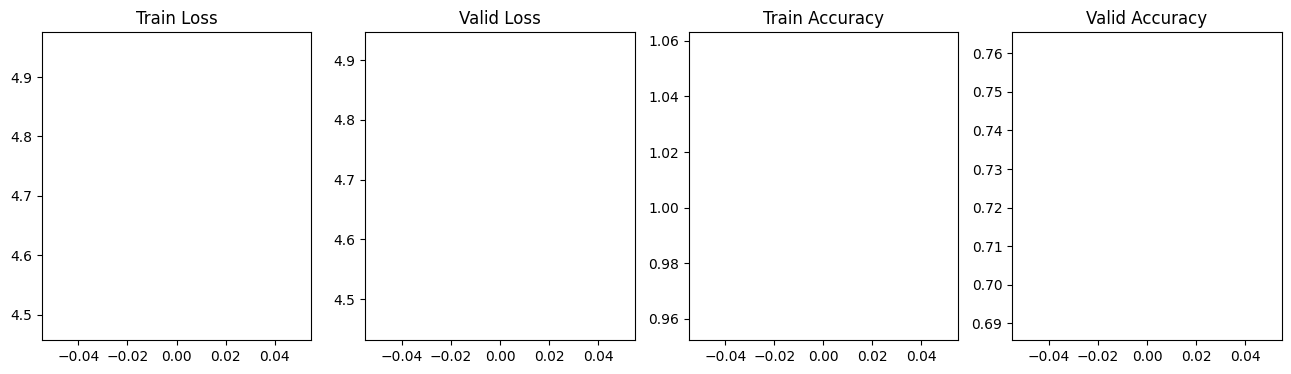

  4%|▍         | 2/51 [02:28<1:01:03, 74.76s/it]

SAVED-MODEL
Epoch: 2, Train Loss: 4.654666505308232, Train Accuracy: 1.0210936450356038, Valid Loss: 4.657312576587383, Valid Acc: 0.9673518742442564
SAVED-MODEL
Epoch: 3, Train Loss: 4.624745866172334, Train Accuracy: 1.2360607282009943, Valid Loss: 4.641892836644099, Valid Acc: 0.7255139056831923


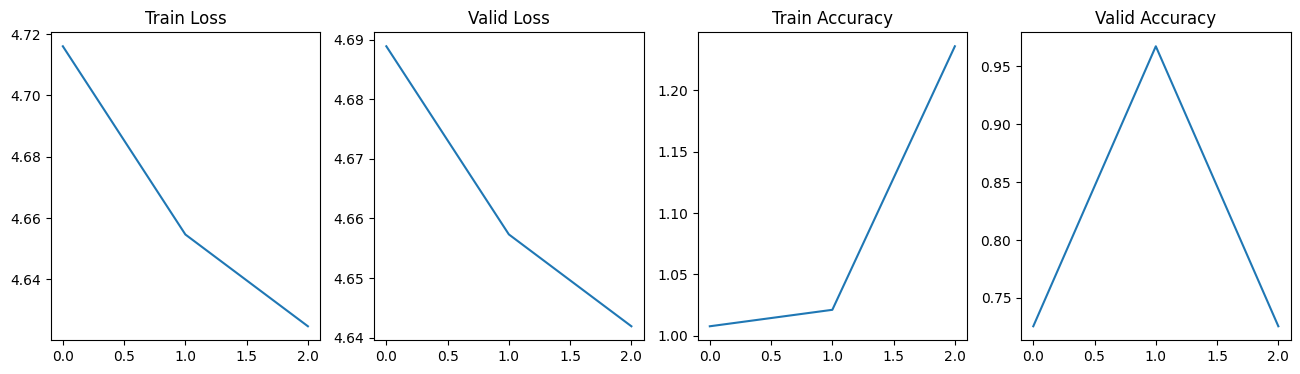

  8%|▊         | 4/51 [05:00<59:16, 75.66s/it]  

SAVED-MODEL
Epoch: 4, Train Loss: 4.609365707788712, Train Accuracy: 1.3838505978772, Valid Loss: 4.6322437066298265, Valid Acc: 0.9673518742442564
SAVED-MODEL
Epoch: 5, Train Loss: 4.594695405063466, Train Accuracy: 1.639124009136101, Valid Loss: 4.626596047328069, Valid Acc: 1.0882708585247884


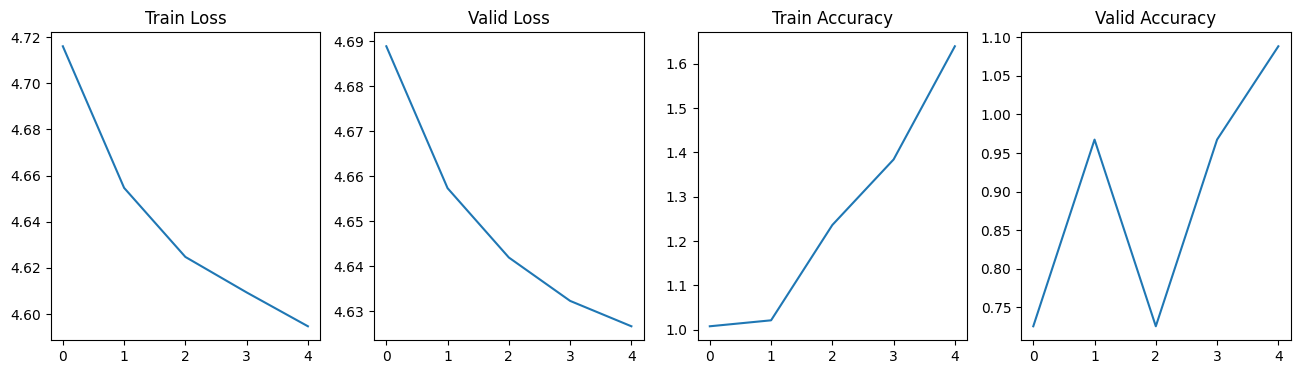

 12%|█▏        | 6/51 [07:35<57:27, 76.62s/it]

SAVED-MODEL
Epoch: 6, Train Loss: 4.580115420186622, Train Accuracy: 1.6928657799274487, Valid Loss: 4.620490147517278, Valid Acc: 1.3301088270858525
SAVED-MODEL
Epoch: 7, Train Loss: 4.568957826011201, Train Accuracy: 1.8540910923014913, Valid Loss: 4.615653624901404, Valid Acc: 1.2091898428053205


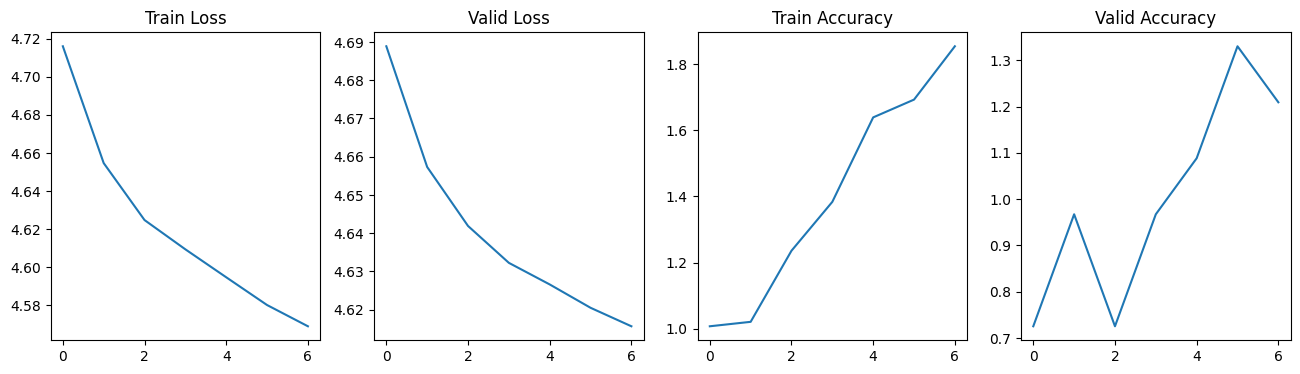

 16%|█▌        | 8/51 [10:09<54:58, 76.70s/it]

SAVED-MODEL
Epoch: 8, Train Loss: 4.563023192250831, Train Accuracy: 1.9481391911863495, Valid Loss: 4.611270060906043, Valid Acc: 1.2091898428053205
SAVED-MODEL
Epoch: 9, Train Loss: 4.550089053618602, Train Accuracy: 2.2974607013301087, Valid Loss: 4.607120917393611, Valid Acc: 1.3301088270858525


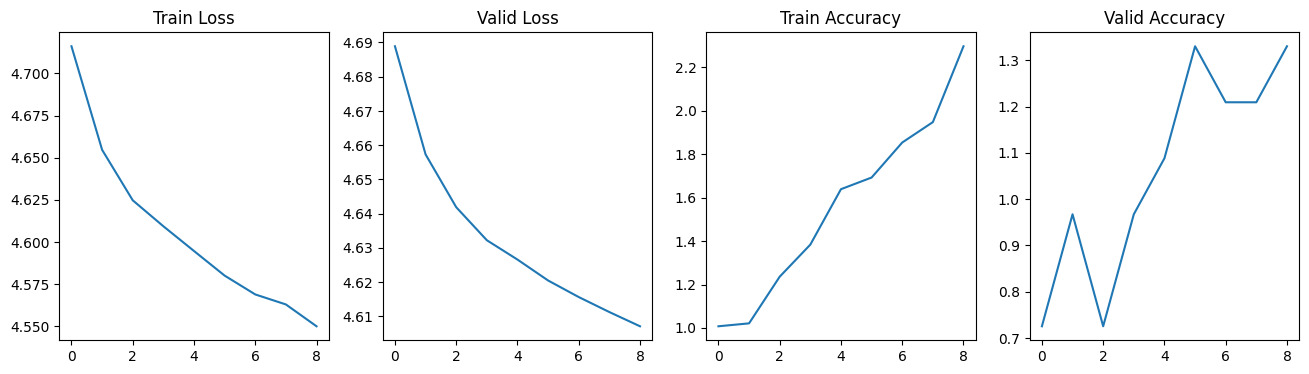

 20%|█▉        | 10/51 [12:41<52:12, 76.39s/it]

SAVED-MODEL
Epoch: 10, Train Loss: 4.541151340191181, Train Accuracy: 2.404944242912804, Valid Loss: 4.602724368755634, Valid Acc: 1.4510278113663846
SAVED-MODEL
Epoch: 11, Train Loss: 4.528680137080005, Train Accuracy: 2.8886201800349323, Valid Loss: 4.598927901341365, Valid Acc: 1.4510278113663846


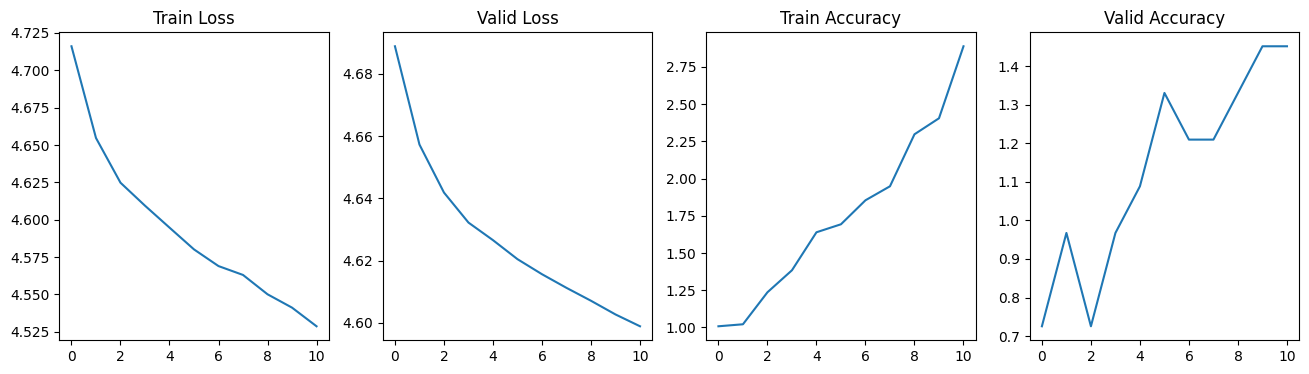

 24%|██▎       | 12/51 [15:16<49:53, 76.75s/it]

SAVED-MODEL
Epoch: 12, Train Loss: 4.517591908446744, Train Accuracy: 3.0901518205024856, Valid Loss: 4.5948274318988505, Valid Acc: 1.6928657799274487
SAVED-MODEL
Epoch: 13, Train Loss: 4.508858566610222, Train Accuracy: 3.305118903667876, Valid Loss: 4.590484399061936, Valid Acc: 1.8137847642079807


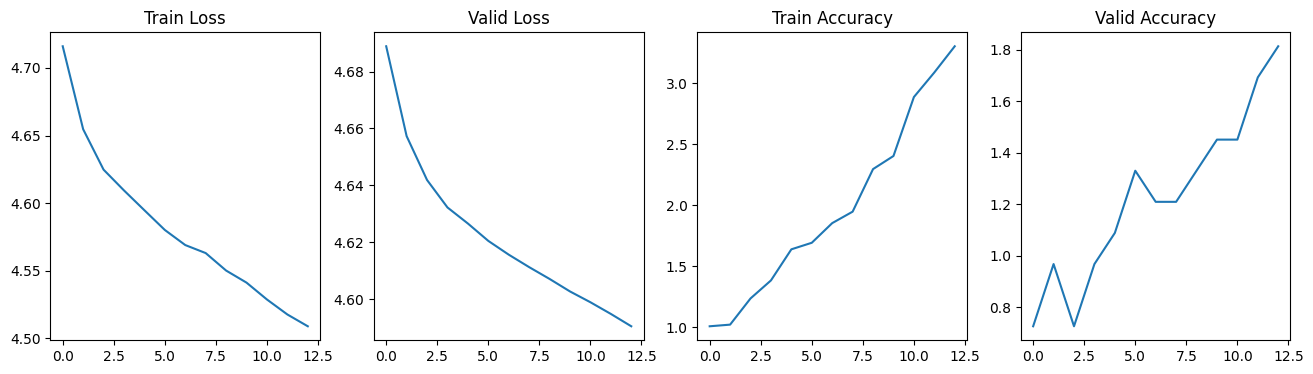

 27%|██▋       | 14/51 [17:49<47:19, 76.74s/it]

SAVED-MODEL
Epoch: 14, Train Loss: 4.499049716525608, Train Accuracy: 3.4932151014375923, Valid Loss: 4.586588015923133, Valid Acc: 1.8137847642079807
SAVED-MODEL
Epoch: 15, Train Loss: 4.488513530829014, Train Accuracy: 3.815665726185678, Valid Loss: 4.582365586207463, Valid Acc: 1.6928657799274487


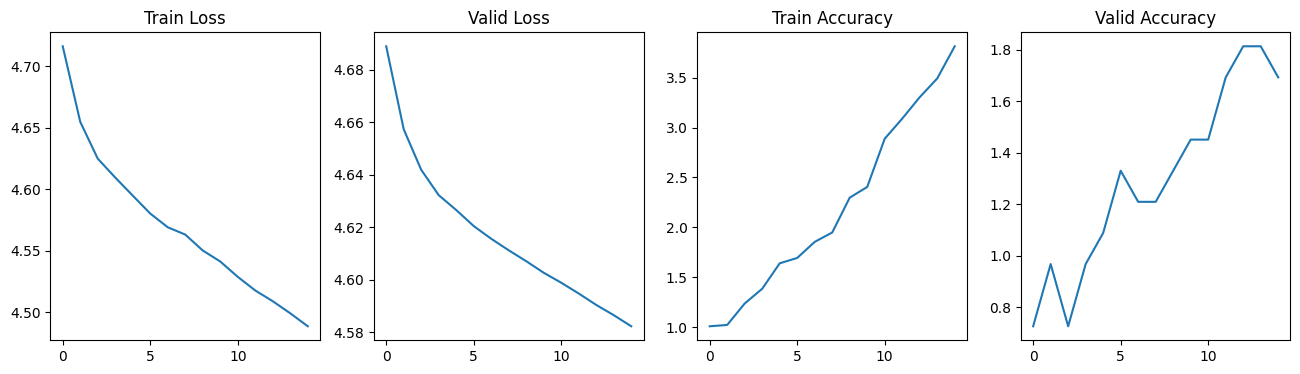

 31%|███▏      | 16/51 [20:22<44:47, 76.77s/it]

SAVED-MODEL
Epoch: 16, Train Loss: 4.4799060128692885, Train Accuracy: 4.044068252048905, Valid Loss: 4.578004030080942, Valid Acc: 1.8137847642079807
SAVED-MODEL
Epoch: 17, Train Loss: 4.467651921459752, Train Accuracy: 4.447131532984012, Valid Loss: 4.574571132659912, Valid Acc: 1.9347037484885128


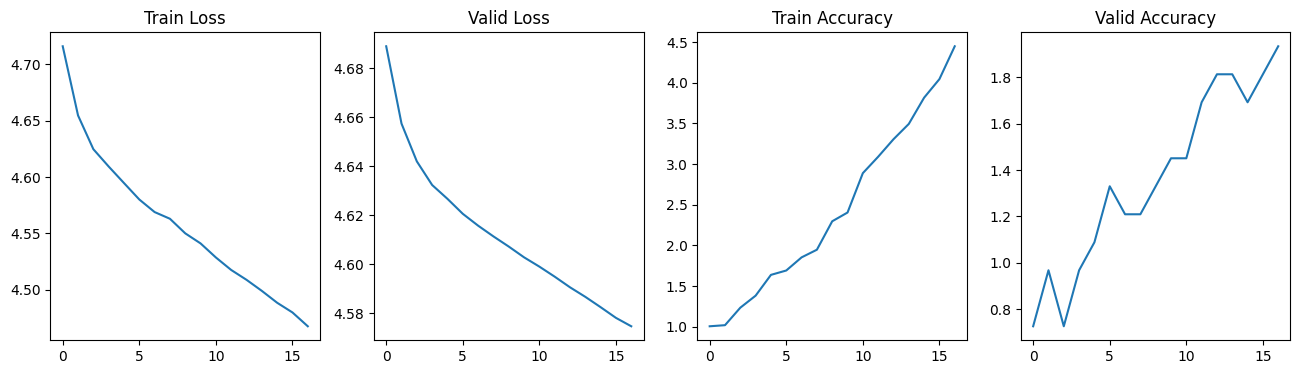

 35%|███▌      | 18/51 [22:54<41:59, 76.33s/it]

SAVED-MODEL
Epoch: 18, Train Loss: 4.458570354005211, Train Accuracy: 4.877065699314793, Valid Loss: 4.570630660423865, Valid Acc: 2.0556227327690446
SAVED-MODEL
Epoch: 19, Train Loss: 4.449554398528531, Train Accuracy: 5.2666935375520625, Valid Loss: 4.566432145925669, Valid Acc: 1.9347037484885128


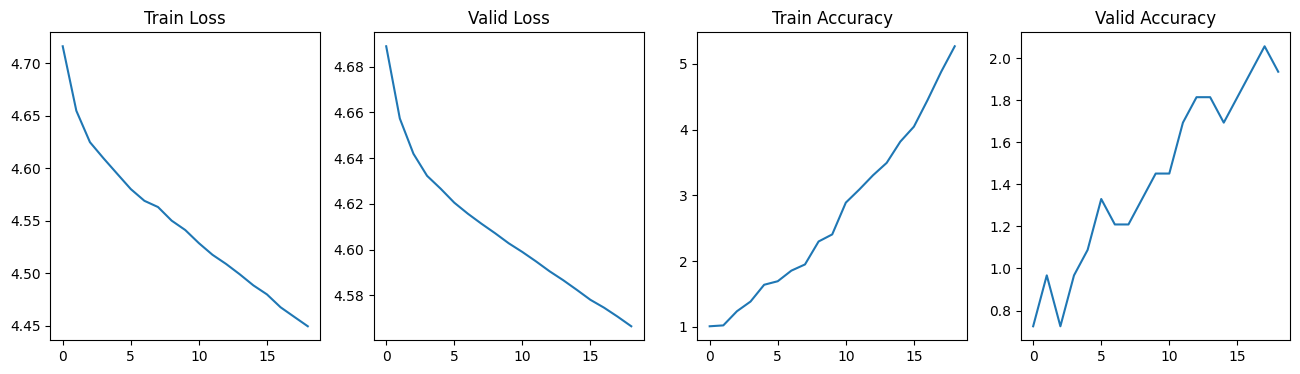

 39%|███▉      | 20/51 [25:27<39:29, 76.44s/it]

SAVED-MODEL
Epoch: 20, Train Loss: 4.437713301079905, Train Accuracy: 5.750369474674191, Valid Loss: 4.562550691457895, Valid Acc: 2.0556227327690446
SAVED-MODEL
Epoch: 21, Train Loss: 4.4288195300306015, Train Accuracy: 5.7772403600698645, Valid Loss: 4.5591008479778585, Valid Acc: 1.9347037484885128


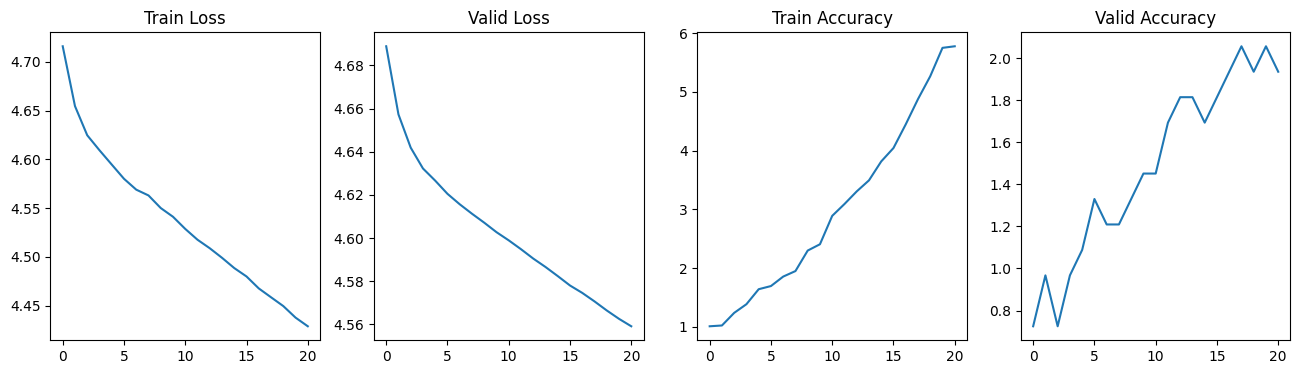

 43%|████▎     | 22/51 [28:01<37:03, 76.67s/it]

SAVED-MODEL
Epoch: 22, Train Loss: 4.416949027623886, Train Accuracy: 6.234045411796319, Valid Loss: 4.554748388437124, Valid Acc: 2.0556227327690446
SAVED-MODEL
Epoch: 23, Train Loss: 4.4094288940103645, Train Accuracy: 6.4758833803573825, Valid Loss: 4.550989847916823, Valid Acc: 1.9347037484885128


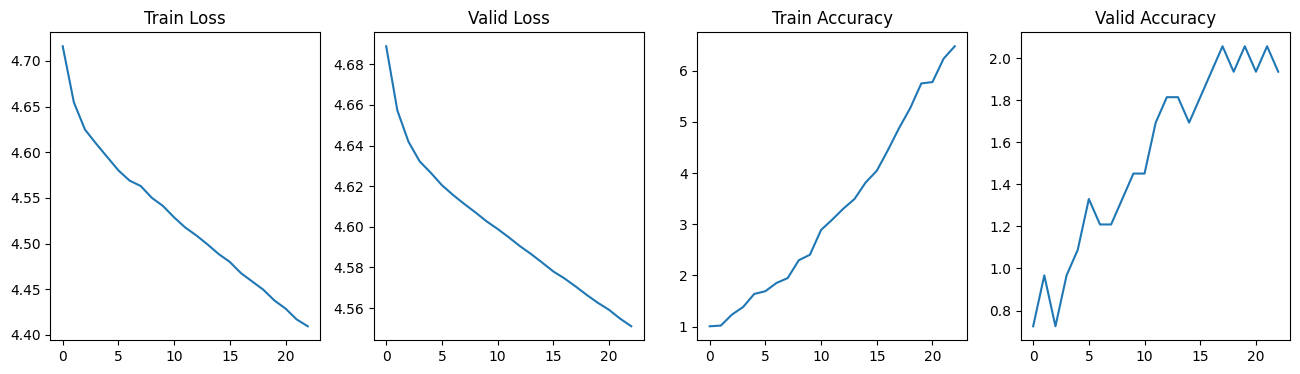

 47%|████▋     | 24/51 [30:34<34:30, 76.67s/it]

SAVED-MODEL
Epoch: 24, Train Loss: 4.399176907335591, Train Accuracy: 6.70428590622061, Valid Loss: 4.546979353978084, Valid Acc: 1.9347037484885128
SAVED-MODEL
Epoch: 25, Train Loss: 4.389272457514053, Train Accuracy: 7.48354158269515, Valid Loss: 4.543396803048941, Valid Acc: 1.9347037484885128


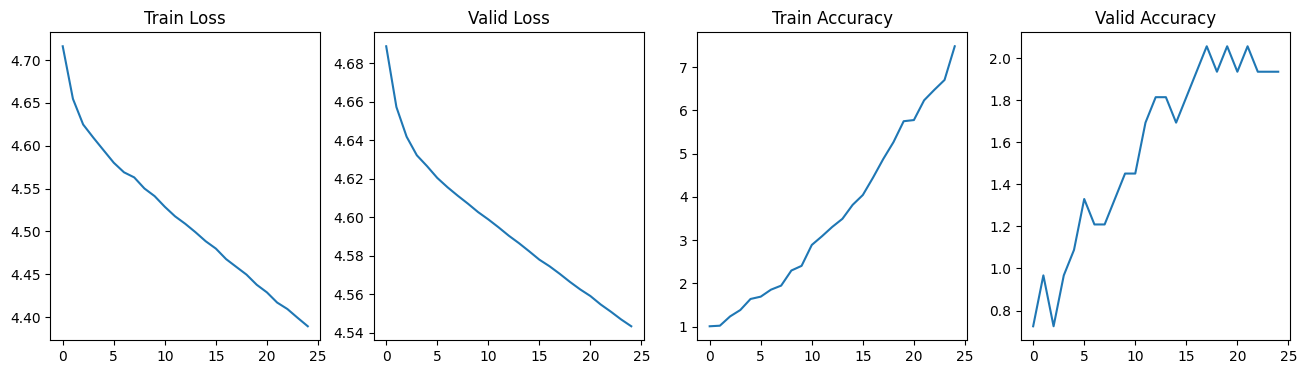

 51%|█████     | 26/51 [33:09<32:06, 77.04s/it]

SAVED-MODEL
Epoch: 26, Train Loss: 4.378305268083882, Train Accuracy: 8.020959290608625, Valid Loss: 4.538779258728027, Valid Acc: 2.176541717049577
SAVED-MODEL
Epoch: 27, Train Loss: 4.3696669187301245, Train Accuracy: 8.329974472658874, Valid Loss: 4.5351595145005446, Valid Acc: 2.418379685610641


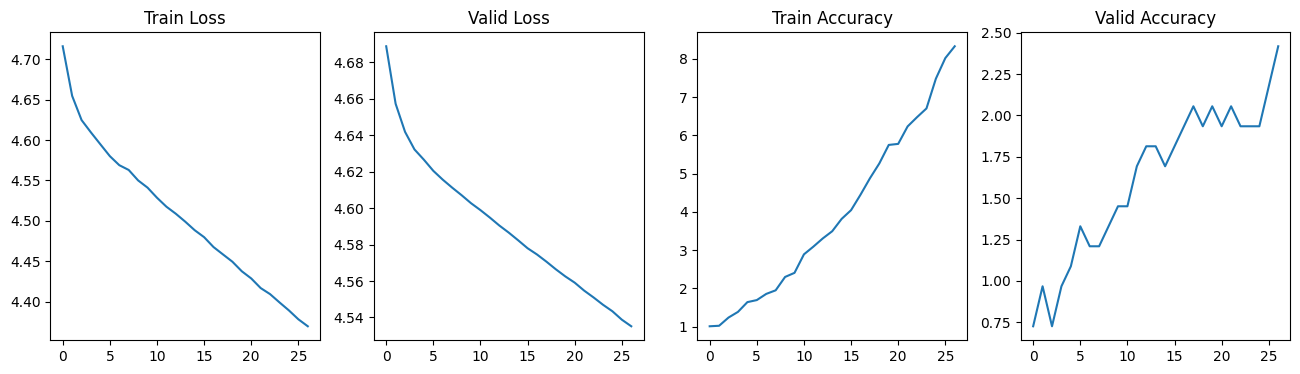

 53%|█████▎    | 27/51 [34:26<30:50, 77.09s/it]

In [6]:
torch.cuda.empty_cache()
device = torch.device('cuda:0')
# load pretrained dataset
# model = models.efficientnet_v2_s(pretrained=True)
# model.classifier[1].out_features = no_classes
model = models.resnet34(pretrained=True)
# changing the last layer to our cause
model.fc = nn.Linear(model.fc.in_features, no_classes)
model.to(device)
criterion = nn.CrossEntropyLoss()
learning_rate = 0.001
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
# optimizer = optim.Adam(params=model.parameters(), lr=learning_rate)
scheduler = lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.1)
# scheduler = lr_scheduler.ReduceLROnPlateau()
n_epochs = 51

result_folder = train_loop(n_epochs, model, optimizer, train_loader, val_loader, device, criterion, scheduler=None)